In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import os

In [2]:
# --- 1. Funciones de utilidad (Necesarias para la preparación del DF) ---

# Replicamos las funciones esenciales para asegurar la ejecución del pipeline completo.
def agregar_lags(df, columna, lags):
    for lag in lags:
        df[f'lag_{lag}'] = df[columna].shift(lag)
    return df

def agregar_medias_moviles(df, columna, ventanas):
    for ventana in ventanas:
        df[f'media_movil_{ventana}'] = df[columna].shift(1).rolling(window=ventana, min_periods=1).mean()
    return df

def agregar_variables_ciclicas(df, columna_mes, columna_fecha):
    df['mes_sin'] = np.sin(2 * np.pi * df[columna_mes] / 12)
    df['mes_cos'] = np.cos(2 * np.pi * df[columna_mes] / 12)
    df['dia_semana_sin'] = np.sin(2 * np.pi * pd.to_datetime(df[columna_fecha]).dt.weekday / 7)
    df['dia_semana_cos'] = np.cos(2 * np.pi * pd.to_datetime(df[columna_fecha]).dt.weekday / 7)
    return df

def agregar_ewma(df, columna, spans):
    for span in spans:
        df[f'ewma_{span}'] = df[columna].shift(1).ewm(span=span, adjust=False).mean()
    return df

def obtener_semestre(mes):
    if 3 <= mes <= 7:
        return 1
    elif 8 <= mes <= 12:
        return 2
    else:
        return 0

def semana_en_semestre(row):
    if row['Semestre'] == 1:
        inicio = pd.Timestamp(year=row['Año'], month=3, day=1)
    elif row['Semestre'] == 2:
        inicio = pd.Timestamp(year=row['Año'], month=8, day=1)
    else:
        return np.nan
    return ((row['Fecha'] - inicio).days // 7) + 1

In [3]:
# --- 2. Preparación y División de Datos (Exógenas y Target) ---

try:
    daily_counts_full = pd.read_csv("Datasets/daily_counts_full.csv")
    print("Dataset cargado desde 'Datasets/daily_counts_full.csv'")
except FileNotFoundError:
    print("ERROR: No se encontró el archivo 'daily_counts_full.csv'.")
    exit(1)

# A. Feature Engineering (Repetimos los pasos para un DF limpio)
for col in ['Accesos']:
    daily_counts_full[col] = daily_counts_full[col].fillna(0).astype(int)
daily_counts_full['Fecha'] = pd.to_datetime(daily_counts_full['Fecha'])
daily_counts_full = daily_counts_full[
    daily_counts_full['Fecha'].dt.weekday != 6 
].reset_index(drop=True)

daily_counts_full = agregar_medias_moviles(daily_counts_full, 'Accesos', [7, 14, 30])
daily_counts_full = agregar_variables_ciclicas(daily_counts_full, 'Mes', 'Fecha')
daily_counts_full = agregar_ewma(daily_counts_full, 'Accesos', [7, 14, 30])
daily_counts_full['Semestre'] = daily_counts_full['Mes'].apply(obtener_semestre)
daily_counts_full['Semana_Semestre'] = daily_counts_full.apply(semana_en_semestre, axis=1)
daily_counts_full['Semana_Certamen'] = daily_counts_full['Semana_Semestre'].isin([6, 7]).astype(int)
daily_counts_full = agregar_lags(daily_counts_full, 'Accesos', [7, 14, 21])

# B. Definición y Split
data_sarimax = daily_counts_full.set_index('Fecha').dropna()

# Conjunto completo de features (exógenas para SARIMAX)
FEATURES = ['Vacaciones', 'Semana_Certamen', 'media_movil_7', 'media_movil_14', 'media_movil_30',
            'mes_sin', 'mes_cos', 'dia_semana_sin', 'dia_semana_cos',
            'lag_7', 'lag_14', 'lag_21', 'ewma_7', 'ewma_14', 'ewma_30']
TARGET = 'Accesos'

X_sarimax = data_sarimax[FEATURES]
y_sarimax = data_sarimax[TARGET]

# Usando el mismo split temporal 80/20
split_point = int(len(data_sarimax) * 0.8)

y_train = y_sarimax.iloc[:split_point]
y_test = y_sarimax.iloc[split_point:]
X_train = X_sarimax.iloc[:split_point]
X_test = X_sarimax.iloc[split_point:]

print(f"\n--- Preparación de Datos Finalizada ---")
print(f"SARIMAX: Datos de entrenamiento: {len(y_train)} | Datos de prueba: {len(y_test)}")

Dataset cargado desde 'Datasets/daily_counts_full.csv'

--- Preparación de Datos Finalizada ---
SARIMAX: Datos de entrenamiento: 256 | Datos de prueba: 64


--- Iniciando Búsqueda de Hiperparámetros (Grid Search) ---
Probando 64 combinaciones posibles...
Progreso: 60 iteraciones completadas.

--- Búsqueda Finalizada ---
Mejor AIC logrado: 3976.46
Mejores parámetros (p,d,q): (0, 0, 1)
Mejores parámetros estacionales (P,D,Q,7): (0, 1, 1, 7)

Resumen del mejor modelo:
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Vacaciones      -1464.8276    271.858     -5.388      0.000   -1997.660    -931.995
Semana_Certamen    94.2522    300.621      0.314      0.754    -494.955     683.459
media_movil_7      -0.3601      0.533     -0.675      0.500      -1.405       0.685
media_movil_14     -1.8179      0.841     -2.162      0.031      -3.466      -0.170
media_movil_30     -0.4376      0.718     -0.610      0.542      -1.845       0.970
mes_sin           -18.2966    168.531     -0.109      0.914    -348.611     312.018
mes_cos        

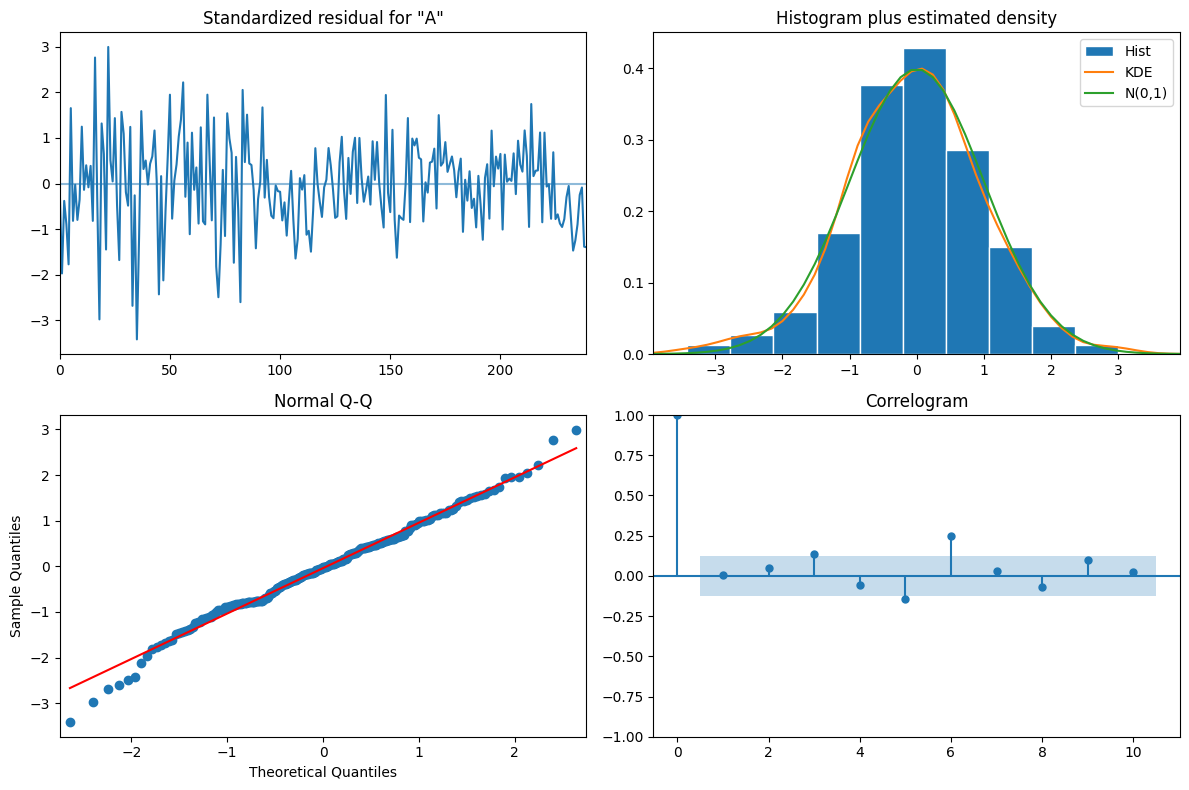

In [4]:
import itertools
import warnings
import sys

# Ignorar advertencias de convergencia para mantener limpia la salida durante la búsqueda
warnings.filterwarnings("ignore")

print("--- Iniciando Búsqueda de Hiperparámetros (Grid Search) ---")

# 1. Definir el rango de parámetros a probar
# p, d, q variarán entre 0 y 2. Puedes aumentar a 3 si tienes mucha potencia de cómputo.
p = d = q = range(0, 2)

# Generar combinaciones para la parte no estacional (p,d,q)
pdq = list(itertools.product(p, d, q))

# Generar combinaciones para la parte estacional (P,D,Q,s) con s=7 (semanal)
seasonal_pdq = [(x[0], x[1], x[2], 7) for x in list(itertools.product(p, d, q))]

best_aic = float("inf")
best_params = None
best_seasonal_params = None
best_model = None

# 2. Ejecutar el bucle de búsqueda
print(f"Probando {len(pdq) * len(seasonal_pdq)} combinaciones posibles...")

counter = 0
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            # Entrenamos un modelo temporal
            mod = sm.tsa.SARIMAX(y_train,
                                 exog=X_train,
                                 order=param,
                                 seasonal_order=param_seasonal,
                                 enforce_stationarity=False,
                                 enforce_invertibility=False)

            # Aumentamos maxiter para evitar ConvergenceWarning
            results = mod.fit(disp=False, maxiter=200, method='powell')
            
            # Guardamos el mejor resultado basado en AIC
            if results.aic < best_aic:
                best_aic = results.aic
                best_params = param
                best_seasonal_params = param_seasonal
                best_model = results
                # print(f"Nuevo mejor AIC: {best_aic:.2f} | Orden: {param} x {param_seasonal}")
                
        except Exception as e:
            continue
        
        counter += 1
        # Barra de progreso simple
        if counter % 10 == 0:
            sys.stdout.write(f"\rProgreso: {counter} iteraciones completadas.")
            sys.stdout.flush()

print(f"\n\n--- Búsqueda Finalizada ---")
print(f"Mejor AIC logrado: {best_aic:.2f}")
print(f"Mejores parámetros (p,d,q): {best_params}")
print(f"Mejores parámetros estacionales (P,D,Q,7): {best_seasonal_params}")

# 3. Asignar el modelo ganador a la variable que usas en la Sección 4
results_sarimax = best_model

# 4. Diagnóstico de residuos (Opcional pero recomendado)
print("\nResumen del mejor modelo:")
print(results_sarimax.summary().tables[1])

# Graficar diagnósticos básicos para verificar que los residuos sean ruido blanco
results_sarimax.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [5]:
# --- 3. Ajuste (Tuning) con los MEJORES parámetros encontrados ---

# Parámetros ganadores según tu Grid Search
best_order = (0, 0, 1)
best_seasonal_order = (0, 1, 1, 7)

print(f"Entrenando SARIMAX con parámetros óptimos: {best_order} x {best_seasonal_order}...")

# Definimos el modelo
model_sarimax = sm.tsa.SARIMAX(
    y_train,
    exog=X_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

# Entrenamos (aumentamos iteraciones para asegurar convergencia)
results_sarimax = model_sarimax.fit(disp=False, maxiter=200, method='powell')

print("Entrenamiento completado.")
print(results_sarimax.summary())

Entrenando SARIMAX con parámetros óptimos: (0, 0, 1) x (0, 1, 1, 7)...
Entrenamiento completado.
                                     SARIMAX Results                                     
Dep. Variable:                           Accesos   No. Observations:                  256
Model:             SARIMAX(0, 0, 1)x(0, 1, 1, 7)   Log Likelihood               -1970.229
Date:                           Thu, 27 Nov 2025   AIC                           3976.458
Time:                                   00:21:21   BIC                           4039.109
Sample:                                        0   HQIC                          4001.702
                                           - 256                                         
Covariance Type:                             opg                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Vacaciones     

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("--- 4. Evaluación de rendimiento en el set de prueba ---")

# 1. Generar predicciones
# El inicio es justo después del último dato de entrenamiento
start_pos = len(y_train)
end_pos = start_pos + len(y_test) - 1

# Hacemos la predicción usando las variables exógenas de prueba (X_test)
predicciones = results_sarimax.predict(
    start=start_pos,
    end=end_pos,
    exog=X_test
)

# Nota: Si tus datos son conteos (no pueden ser negativos), forzamos ceros.
predicciones = np.maximum(predicciones, 0)

# Asignar el índice de fechas de y_test para que coincidan al graficar
predicciones.index = y_test.index

# 2. Calcular métricas de error
mae = mean_absolute_error(y_test, predicciones)
mse = mean_squared_error(y_test, predicciones)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predicciones)

print(f"R² (Coeficiente de determinación): {r2:.4f}")
print(f"MAE (Error Absoluto Medio): {mae:.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f}")

--- 4. Evaluación de rendimiento en el set de prueba ---
R² (Coeficiente de determinación): 0.7269
MAE (Error Absoluto Medio): 624.38
RMSE (Raíz del Error Cuadrático Medio): 773.64


--- 5. Visualización de Resultados ---


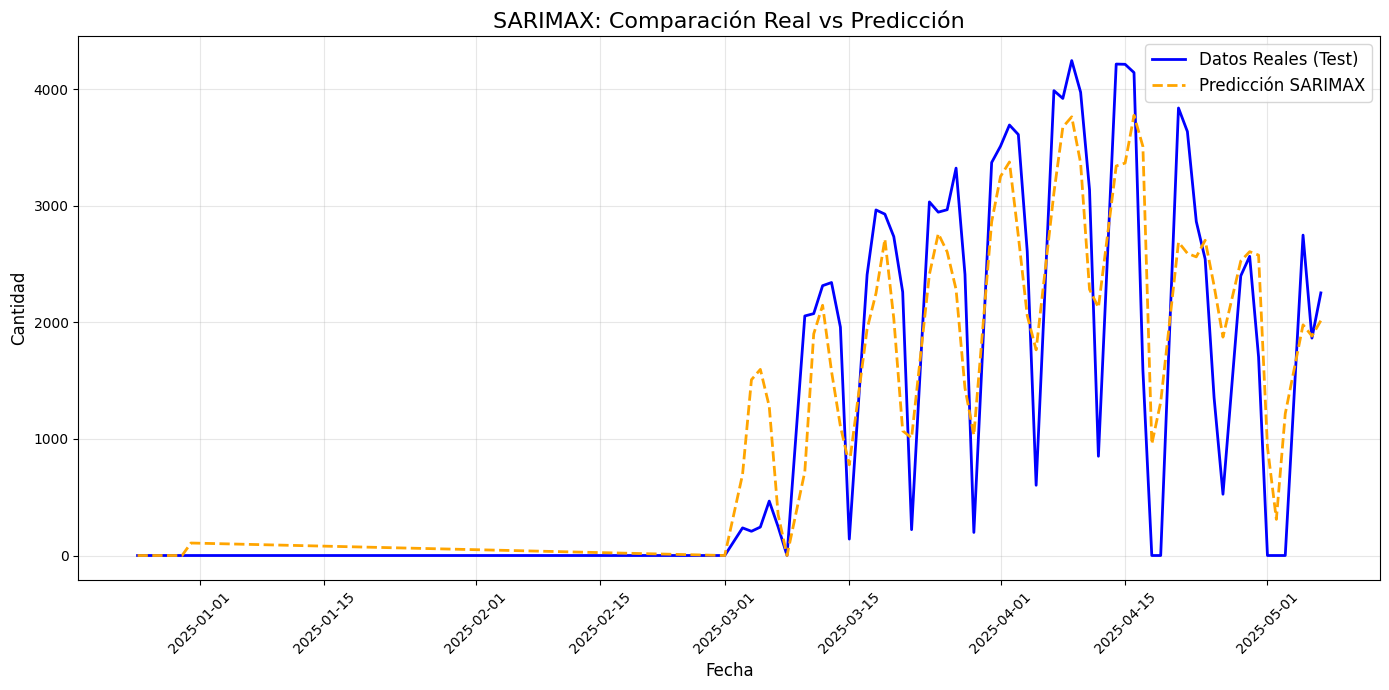

In [11]:
print("--- 5. Visualización de Resultados ---")

plt.figure(figsize=(14, 7))

# Graficar datos reales
plt.plot(y_test.index, y_test, label='Datos Reales (Test)', color='blue', linewidth=2)

# Graficar predicciones
plt.plot(y_test.index, predicciones, label='Predicción SARIMAX', color='orange', linestyle='--', linewidth=2)

plt.title('SARIMAX: Comparación Real vs Predicción', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
import pickle

print("--- 6. Generación del Modelo Final (Producción) ---")

# 1. Unir train y test para tener el dataset completo
# (Asumiendo que 'data_sarimax' contiene todo el histórico limpio)
X_full = data_sarimax[FEATURES]
y_full = data_sarimax[TARGET]

print(f"Entrenando modelo final con el 100% de los datos ({len(y_full)} registros)...")

# 2. Re-entrenar con la configuración ganadora
final_model = sm.tsa.SARIMAX(
    y_full,
    exog=X_full,
    order=best_order,  # (0, 0, 1)
    seasonal_order=best_seasonal_order, # (0, 1, 1, 7)
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False, maxiter=200, method='powell')

print("¡Modelo Maestro entrenado exitosamente!")
print(f"AIC Final: {final_results.aic:.2f}")

# 3. Guardar el modelo en un archivo para usarlo después (ej. en una app o web)
filename = 'modelo_sarimax_final.pkl'
with open(filename, 'wb') as pkl:
    pickle.dump(final_results, pkl)

print(f"\nEl modelo ha sido guardado como '{filename}'.")
print("Ahora puedes usar este archivo para realizar pronósticos futuros.")

--- 6. Generación del Modelo Final (Producción) ---
Entrenando modelo final con el 100% de los datos (320 registros)...
¡Modelo Maestro entrenado exitosamente!
AIC Final: 5014.29

El modelo ha sido guardado como 'modelo_sarimax_final.pkl'.
Ahora puedes usar este archivo para realizar pronósticos futuros.


--- 7. Pronóstico a Futuro (Corrección de 15 variables) ---
Generando predicción para: 2025-05-08 al 2025-05-14

--- Pronóstico Exitoso ---
       Fecha  Prediccion
0 2025-05-08        1963
1 2025-05-09        1378
2 2025-05-10         853
3 2025-05-11         869
4 2025-05-12        1102
5 2025-05-13        2116
6 2025-05-14        2656


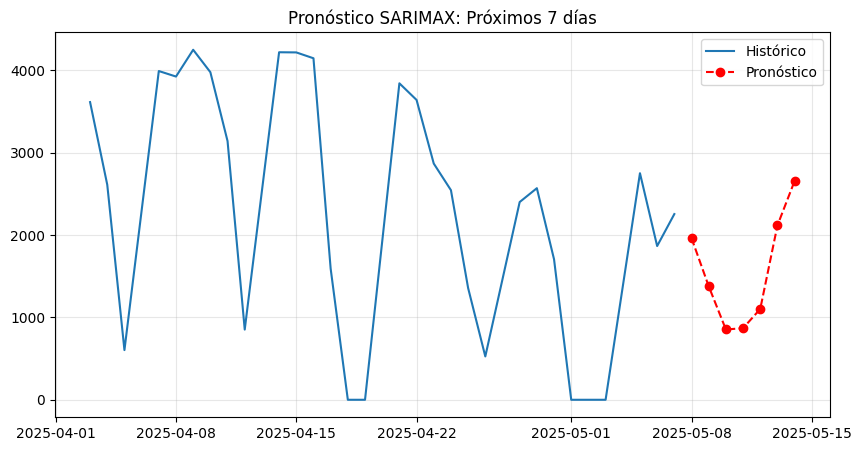

In [17]:
import pandas as pd
import numpy as np

print("--- 7. Pronóstico a Futuro (Corrección de 15 variables) ---")

# 1. Configuración
DAYS_TO_PREDICT = 7
last_date = daily_counts_full['Fecha'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=DAYS_TO_PREDICT)

# Copia de seguridad para ir agregando predicciones sin tocar el original
current_data = daily_counts_full.copy()

future_predictions = []

print(f"Generando predicción para: {future_dates[0].date()} al {future_dates[-1].date()}")

# 2. Bucle Recursivo
for date in future_dates:
    # --- A. Calcular Fechas y Cíclicas ---
    mes = date.month
    weekday = date.weekday()
    
    # 1. Cíclicas (4 vars)
    mes_sin = np.sin(2 * np.pi * mes / 12)
    mes_cos = np.cos(2 * np.pi * mes / 12)
    dia_sin = np.sin(2 * np.pi * weekday / 7)
    dia_cos = np.cos(2 * np.pi * weekday / 7)
    
    # 2. Eventos (2 vars) - Ajusta según tu calendario real
    es_vacaciones = 0 # Asumimos 0 por defecto
    es_semana_certamen = 0 # Asumimos 0 por defecto
    
    # --- B. Calcular Variables dependientes del pasado (9 vars) ---
    # Accedemos a la columna 'Accesos' actualizada
    historia = current_data['Accesos']
    
    # Medias Móviles
    mm_7 = historia.iloc[-7:].mean()
    mm_14 = historia.iloc[-14:].mean()
    mm_30 = historia.iloc[-30:].mean()
    
    # Lags (Valores pasados exactos)
    lag_7 = historia.iloc[-7]
    lag_14 = historia.iloc[-14]
    lag_21 = historia.iloc[-21]
    
    # EWMA (Media móvil exponencial)
    # Calculamos sobre toda la serie y tomamos el último valor
    ewma_7 = historia.ewm(span=7, adjust=False).mean().iloc[-1]
    ewma_14 = historia.ewm(span=14, adjust=False).mean().iloc[-1]
    ewma_30 = historia.ewm(span=30, adjust=False).mean().iloc[-1]

    # --- C. Crear DataFrame con las 15 FEATURES exactas ---
    # El orden debe ser idéntico a tu lista FEATURES original
    exog_future = pd.DataFrame({
        'Vacaciones': [es_vacaciones],
        'Semana_Certamen': [es_semana_certamen],
        'media_movil_7': [mm_7],
        'media_movil_14': [mm_14],
        'media_movil_30': [mm_30],
        'mes_sin': [mes_sin],
        'mes_cos': [mes_cos],
        'dia_semana_sin': [dia_sin],
        'dia_semana_cos': [dia_cos],
        'lag_7': [lag_7],
        'lag_14': [lag_14],
        'lag_21': [lag_21],
        'ewma_7': [ewma_7],
        'ewma_14': [ewma_14],
        'ewma_30': [ewma_30]
    }, index=[date])

    # --- D. Predecir ---
    forecast = final_results.get_forecast(steps=1, exog=exog_future)
    pred_value = np.maximum(forecast.predicted_mean.iloc[0], 0)
    
    # --- E. Actualizar para el siguiente ciclo ---
    future_predictions.append(pred_value)
    
    # Agregamos la predicción como si fuera un dato real para los cálculos de mañana
    new_row = pd.DataFrame({'Fecha': [date], 'Accesos': [pred_value]})
    current_data = pd.concat([current_data, new_row], ignore_index=True)

# 3. Resultado
df_forecast = pd.DataFrame({
    'Fecha': future_dates,
    'Prediccion': np.round(future_predictions).astype(int)
})

print("\n--- Pronóstico Exitoso ---")
print(df_forecast)

# Graficar
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
# Mostramos el último mes real y la predicción
plt.plot(daily_counts_full['Fecha'].iloc[-30:], daily_counts_full['Accesos'].iloc[-30:], label='Histórico')
plt.plot(df_forecast['Fecha'], df_forecast['Prediccion'], label='Pronóstico', linestyle='--', marker='o', color='red')
plt.title(f'Pronóstico SARIMAX: Próximos {DAYS_TO_PREDICT} días')
plt.legend()
plt.grid(alpha=0.3)
plt.show()